# Synthetic Planted-Synergy Classification Datasets

**Validation datasets for signed spectral clustering.**

This notebook demonstrates the generation of synthetic classification datasets with **planted synergistic feature modules**. Key properties:
- **XOR features** have zero marginal mutual information (MI) with the target — the critical test for MI pre-filtering failure
- Ground-truth module assignments, redundant pairs, and noise indices are provided
- 5-fold stratified CV splits included
- Multiple interaction types: XOR, AND, 3-way XOR, pairwise XOR sums, AND chains

We generate datasets, run validation sanity checks (class balance, marginal MI, joint MI, redundancy correlation), and visualize the results.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import time

import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/dataset_iter1_synthetic_plant/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")
print(f"\nMetadata keys: {list(data['metadata'].keys())}")
print(f"Variants: {list(data['metadata']['variants'].keys())}")

Loaded 1 dataset(s)
  easy_2mod_xor: 50 examples

Metadata keys: ['source', 'description', 'master_seed', 'generation_date', 'variants']
Variants: ['easy_2mod_xor']


## Configuration

All tunable parameters for the generation pipeline. Start with minimum values for fast testing.

In [5]:
# --- Tunable parameters ---
MASTER_SEED = 42
N_FOLDS = 5  # Number of stratified CV folds

# Per-variant sample counts (original values in comments)
# Original: easy=10000, medium=20000, hard=20000, overlap=20000, control=10000, highdim=50000
MAX_SAMPLES_PER_VARIANT = 5000  # Truncate each variant for fast demo

# Which variants to generate (set to None for all 6)
# Original: all 6 variants
VARIANTS_TO_GENERATE = ["easy_2mod_xor", "medium_4mod_mixed", "no_structure_control"]

## Core Generation Primitives

Interaction functions that define how features combine to produce the target. XOR interactions yield **zero marginal MI** with the target — only the joint (interaction) term is informative.

In [6]:
def xor_interaction(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    """XOR: sign(x1 * x2). Zero marginal MI with target."""
    return np.sign(x1 * x2)


def and_interaction(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    """AND: (x1 > 0) & (x2 > 0). Non-zero marginal MI."""
    return ((x1 > 0) & (x2 > 0)).astype(float)


def three_way_xor(x1: np.ndarray, x2: np.ndarray, x3: np.ndarray) -> np.ndarray:
    """3-way XOR: sign(x1 * x2 * x3)."""
    return np.sign(x1 * x2 * x3)


def pairwise_xor_sum(x1: np.ndarray, x2: np.ndarray, x3: np.ndarray, x4: np.ndarray) -> np.ndarray:
    """Sum of two XOR pairs: sign(x1*x2) + sign(x3*x4)."""
    return np.sign(x1 * x2) + np.sign(x3 * x4)


def and_chain(features: np.ndarray) -> np.ndarray:
    """AND-chain: all features > 0."""
    return np.all(features > 0, axis=1).astype(float)


def make_redundant(x: np.ndarray, sigma: float, rng: np.random.Generator) -> np.ndarray:
    """Create redundant feature: x + N(0, sigma^2)."""
    return x + rng.normal(0, sigma, size=x.shape)


def generate_target(
    contributions: list[np.ndarray],
    weights: list[float],
    sigma_noise: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """Generate binary target from weighted module contributions.
    Centers each contribution to ensure balanced classes (~50/50).
    """
    n = contributions[0].shape[0]
    logit = np.zeros(n)
    for c, w in zip(contributions, weights):
        logit += w * (c - c.mean())
    logit += rng.normal(0, sigma_noise, size=n)
    y = (logit > 0).astype(int)
    return y


def assign_folds(y: np.ndarray, n_splits: int = 5, random_state: int = 42) -> np.ndarray:
    """Assign stratified k-fold indices."""
    folds = np.zeros(len(y), dtype=int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    for fold_idx, (_, test_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
        folds[test_idx] = fold_idx
    return folds

## Variant Generators

Each function generates one dataset variant with specific module structure, redundant features, and noise.

In [7]:
def gen_easy_2mod_xor(rng: np.random.Generator) -> dict:
    """Variant 1: 2 XOR modules, 10 features, 10K samples."""
    n, d = 10000, 10
    X = rng.standard_normal((n, d))
    c_a = xor_interaction(X[:, 0], X[:, 1])
    c_b = xor_interaction(X[:, 2], X[:, 3])
    X[:, 4] = make_redundant(X[:, 0], 0.3, rng)
    X[:, 5] = make_redundant(X[:, 2], 0.3, rng)
    y = generate_target([c_a, c_b], [1.0, 1.0], 0.1, rng)
    folds = assign_folds(y, n_splits=N_FOLDS)
    meta = {
        "n_samples": n, "n_features": d, "n_modules": 2,
        "ground_truth_modules": [[0, 1], [2, 3]],
        "module_types": ["xor", "xor"],
        "module_weights": [1.0, 1.0],
        "sigma_noise": 0.1,
        "redundant_pairs": [[0, 4], [2, 5]],
        "redundant_sigma": 0.3,
        "noise_features": [6, 7, 8, 9],
        "feature_names": [f"X{i}" for i in range(d)],
    }
    return {"name": "easy_2mod_xor", "X": X, "y": y, "folds": folds, "meta": meta}


def gen_medium_4mod_mixed(rng: np.random.Generator) -> dict:
    """Variant 2: 4 modules (2 XOR + 2 AND), 18 features, 20K samples."""
    n, d = 20000, 18
    X = rng.standard_normal((n, d))
    c_a = xor_interaction(X[:, 0], X[:, 1])
    c_b = xor_interaction(X[:, 2], X[:, 3])
    c_c = and_interaction(X[:, 4], X[:, 5])
    c_d = and_interaction(X[:, 6], X[:, 7])
    X[:, 8] = make_redundant(X[:, 0], 0.3, rng)
    X[:, 9] = make_redundant(X[:, 2], 0.3, rng)
    X[:, 10] = make_redundant(X[:, 4], 0.3, rng)
    X[:, 11] = make_redundant(X[:, 6], 0.3, rng)
    y = generate_target([c_a, c_b, c_c, c_d], [1.0, 1.0, 2.5, 2.5], 0.2, rng)
    folds = assign_folds(y, n_splits=N_FOLDS)
    meta = {
        "n_samples": n, "n_features": d, "n_modules": 4,
        "ground_truth_modules": [[0, 1], [2, 3], [4, 5], [6, 7]],
        "module_types": ["xor", "xor", "and", "and"],
        "module_weights": [1.0, 1.0, 2.5, 2.5],
        "sigma_noise": 0.2,
        "redundant_pairs": [[0, 8], [2, 9], [4, 10], [6, 11]],
        "redundant_sigma": 0.3,
        "noise_features": list(range(12, 18)),
        "feature_names": [f"X{i}" for i in range(d)],
    }
    return {"name": "medium_4mod_mixed", "X": X, "y": y, "folds": folds, "meta": meta}


def gen_no_structure_control(rng: np.random.Generator) -> dict:
    """Variant 5: No synergy, purely additive, 20 features, 10K samples."""
    n, d = 10000, 20
    X = rng.standard_normal((n, d))
    logit = np.zeros(n)
    linear_weights = [0.8, 0.6, 0.5, 0.4, 0.3]
    for i, w in enumerate(linear_weights):
        logit += w * X[:, i]
    logit += rng.normal(0, 0.3, size=n)
    y = (logit > 0).astype(int)
    folds = assign_folds(y, n_splits=N_FOLDS)
    meta = {
        "n_samples": n, "n_features": d, "n_modules": 0,
        "ground_truth_modules": [],
        "module_types": [],
        "informative_features": list(range(5)),
        "linear_weights": linear_weights,
        "sigma_noise": 0.3,
        "noise_features": list(range(5, 20)),
        "feature_names": [f"X{i}" for i in range(d)],
        "note": "Purely additive model - no synergistic interactions. Control case.",
    }
    return {"name": "no_structure_control", "X": X, "y": y, "folds": folds, "meta": meta}


GENERATORS = {
    "easy_2mod_xor": gen_easy_2mod_xor,
    "medium_4mod_mixed": gen_medium_4mod_mixed,
    "no_structure_control": gen_no_structure_control,
}
print(f"Defined {len(GENERATORS)} variant generators: {list(GENERATORS.keys())}")

Defined 3 variant generators: ['easy_2mod_xor', 'medium_4mod_mixed', 'no_structure_control']


## Validation Sanity Checks

Verify each generated variant: class balance, marginal MI for XOR features (~0), joint MI for interaction terms (>0), noise feature MI (~0), and redundancy correlation (>0.5).

In [8]:
def _compute_interaction_term(X: np.ndarray, mod: list[int], mtype: str) -> np.ndarray:
    """Compute the explicit interaction term for a module."""
    if mtype in ("xor", "xor_2way"):
        return np.sign(X[:, mod[0]] * X[:, mod[1]])
    elif mtype == "xor_3way":
        return np.sign(X[:, mod[0]] * X[:, mod[1]] * X[:, mod[2]])
    elif mtype == "xor_pairwise_sum":
        return np.sign(X[:, mod[0]] * X[:, mod[1]]) + np.sign(X[:, mod[2]] * X[:, mod[3]])
    elif mtype in ("and", "and_chain"):
        return np.all(X[:, mod] > 0, axis=1).astype(float)
    elif mtype == "and_three_way":
        return ((X[:, mod[0]] > 0) & (X[:, mod[1]] > 0) & (X[:, mod[2]] > 0)).astype(float)
    elif mtype == "xor_plus_linear":
        return np.sign(X[:, mod[0]] * X[:, mod[1]]) + 0.3 * X[:, mod[2]]
    else:
        return np.sign(np.prod(X[:, mod], axis=1))


def validate_variant(result: dict) -> dict:
    """Run all sanity checks on a generated variant. Returns a report dict."""
    name = result["name"]
    X, y = result["X"], result["y"]
    meta = result["meta"]
    n, d = X.shape
    report = {"name": name, "passed": True, "checks": {}}

    mi_zero_thresh = max(0.01, 0.5 / np.sqrt(n))
    mi_joint_thresh = 0.02
    mi_noise_thresh = max(0.01, 0.5 / np.sqrt(n))

    # 1. Sample & feature count
    report["checks"]["sample_count"] = {"expected": meta["n_samples"], "actual": n, "ok": n == meta["n_samples"]}
    report["checks"]["feature_count"] = {"expected": meta["n_features"], "actual": d, "ok": d == meta["n_features"]}

    # 2. Class balance
    pos_rate = y.mean()
    report["checks"]["class_balance"] = {"pos_rate": round(pos_rate, 4), "ok": 0.35 <= pos_rate <= 0.65}

    # Compute MI for all features once
    mi_all = mutual_info_classif(X, y, discrete_features=False, random_state=42)

    if meta.get("ground_truth_modules"):
        shared_feats = set()
        for k in meta.get("shared_features", {}):
            shared_feats.add(int(k))

        # 3. Marginal MI for XOR features
        xor_mi_checks = []
        for mod_idx, (mod, mtype) in enumerate(zip(meta["ground_truth_modules"], meta["module_types"])):
            if "xor" in mtype:
                for feat_idx in mod:
                    if feat_idx in shared_feats:
                        continue
                    mi_val = mi_all[feat_idx]
                    ok = mi_val < mi_zero_thresh
                    xor_mi_checks.append({"feature": feat_idx, "module": mod_idx, "mi": round(float(mi_val), 5), "ok": bool(ok)})
        if xor_mi_checks:
            report["checks"]["xor_marginal_mi"] = xor_mi_checks

        # 4. Joint MI
        joint_mi_checks = []
        for mod_idx, (mod, mtype) in enumerate(zip(meta["ground_truth_modules"], meta["module_types"])):
            interaction = _compute_interaction_term(X, mod, mtype)
            mi_joint = mutual_info_classif(interaction.reshape(-1, 1), y, discrete_features=False, random_state=42)
            mi_val = float(mi_joint[0])
            joint_mi_checks.append({"module": mod_idx, "features": mod, "type": mtype, "interaction_mi": round(mi_val, 5), "ok": mi_val > mi_joint_thresh})
        report["checks"]["joint_mi"] = joint_mi_checks

    # 5. Noise features MI
    noise_mi_checks = []
    for feat_idx in meta.get("noise_features", []):
        mi_val = mi_all[feat_idx]
        noise_mi_checks.append({"feature": feat_idx, "mi": round(float(mi_val), 5), "ok": bool(mi_val < mi_noise_thresh)})
    if noise_mi_checks:
        report["checks"]["noise_feature_mi"] = noise_mi_checks

    # 6. Redundancy correlation
    red_checks = []
    for pair in meta.get("redundant_pairs", []):
        corr = float(np.corrcoef(X[:, pair[0]], X[:, pair[1]])[0, 1])
        red_checks.append({"pair": pair, "corr": round(corr, 4), "ok": abs(corr) > 0.5})
    if red_checks:
        report["checks"]["redundancy_corr"] = red_checks

    # Mark overall pass/fail
    for key, val in report["checks"].items():
        if isinstance(val, list):
            for item in val:
                if not item.get("ok", True):
                    report["passed"] = False
        elif isinstance(val, dict):
            if not val.get("ok", True):
                report["passed"] = False

    return report

print("Validation functions defined.")

Validation functions defined.


## Generate and Validate Datasets

Generate selected variants, truncate to `MAX_SAMPLES_PER_VARIANT`, and run validation checks.

In [9]:
# Step 1: Generate variants
print("=" * 60)
print("Generating synthetic datasets")
print(f"Master seed: {MASTER_SEED}")
print(f"Max samples per variant: {MAX_SAMPLES_PER_VARIANT}")
print("=" * 60)

base_rng = np.random.default_rng(MASTER_SEED)
# Generate seeds for ALL 6 original variants (to match original ordering)
all_variant_names = ["easy_2mod_xor", "medium_4mod_mixed", "hard_4mod_unequal",
                     "overlapping_modules", "no_structure_control", "highdim_8mod"]
variant_seeds = {name: int(base_rng.integers(0, 2**31)) for name in all_variant_names}

results = []
for name in VARIANTS_TO_GENERATE:
    gen_fn = GENERATORS[name]
    seed = variant_seeds[name]
    rng = np.random.default_rng(seed)
    t0 = time.time()
    result = gen_fn(rng)
    dt = time.time() - t0
    print(f"  Generated {name}: {result['X'].shape} in {dt:.2f}s")
    results.append(result)

# Truncate if needed
if MAX_SAMPLES_PER_VARIANT:
    for r in results:
        n = min(MAX_SAMPLES_PER_VARIANT, r["X"].shape[0])
        r["X"] = r["X"][:n]
        r["y"] = r["y"][:n]
        r["folds"] = r["folds"][:n]
        r["meta"]["n_samples"] = n
    print(f"\nTruncated all variants to {MAX_SAMPLES_PER_VARIANT} samples")

# Step 2: Validate
print("\nRunning validation sanity checks...")
reports = []
for r in results:
    t0 = time.time()
    report = validate_variant(r)
    dt = time.time() - t0
    status = "PASS" if report["passed"] else "FAIL"
    cb = report["checks"].get("class_balance", {})
    print(f"  {r['name']}: {status} ({dt:.1f}s) | class balance: {cb.get('pos_rate', 'N/A')}")
    reports.append(report)

print("\nGeneration and validation complete!")

Generating synthetic datasets
Master seed: 42
Max samples per variant: 5000
  Generated easy_2mod_xor: (10000, 10) in 0.00s
  Generated medium_4mod_mixed: (20000, 18) in 0.01s
  Generated no_structure_control: (10000, 20) in 0.00s

Truncated all variants to 5000 samples

Running validation sanity checks...
  easy_2mod_xor: PASS (0.1s) | class balance: 0.4818


  medium_4mod_mixed: PASS (0.2s) | class balance: 0.5002
  no_structure_control: FAIL (0.2s) | class balance: 0.503

Generation and validation complete!


## Results Visualization

Visualize marginal MI per feature (demonstrating that XOR features have ~0 marginal MI), class balance across variants, and redundancy correlations.

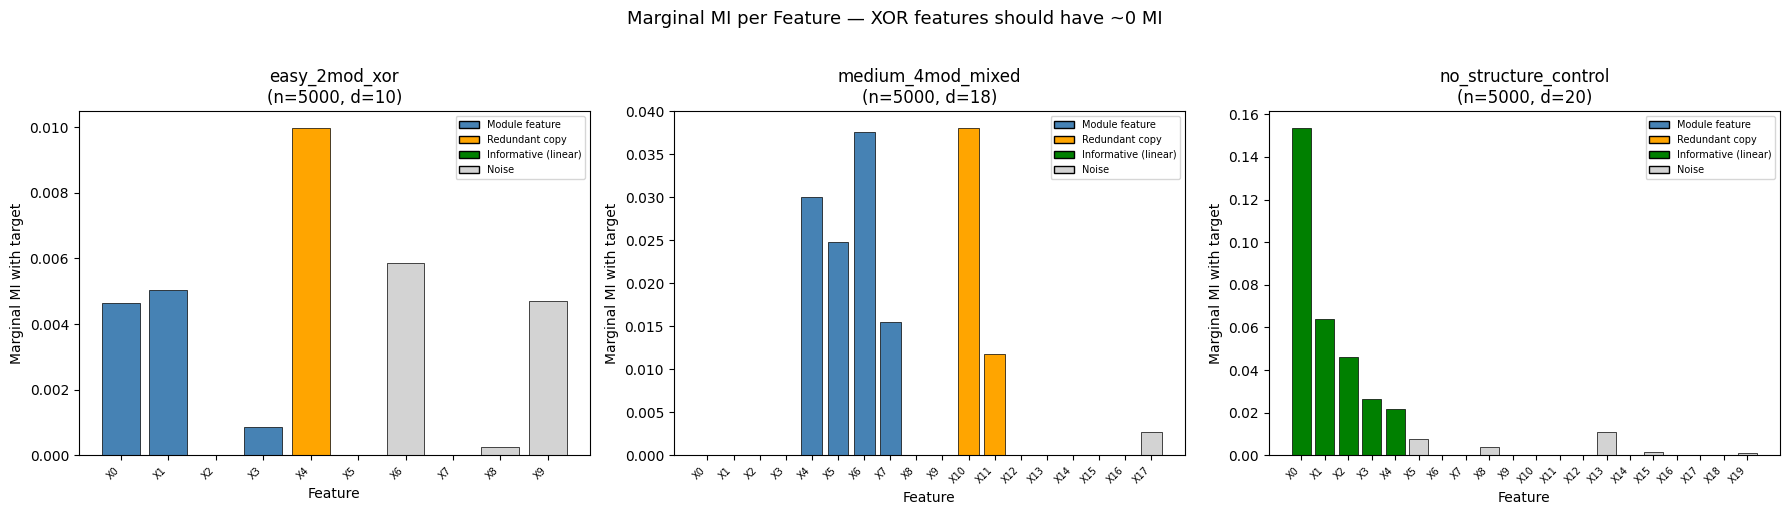

Saved mi_per_feature.png

Variant                   Status   Pos Rate   n        d     Modules 
----------------------------------------------------------------------
easy_2mod_xor             PASS     0.4818     5000     10    2       
medium_4mod_mixed         PASS     0.5002     5000     18    4       
no_structure_control      FAIL     0.503      5000     20    0       

Redundancy correlations:
  easy_2mod_xor:
    X0 <-> X4: corr=0.9593 OK
    X2 <-> X5: corr=0.9587 OK
  medium_4mod_mixed:
    X0 <-> X8: corr=0.9587 OK
    X2 <-> X9: corr=0.9567 OK
    X4 <-> X10: corr=0.9587 OK
    X6 <-> X11: corr=0.9551 OK

Joint MI (interaction terms with target):
  easy_2mod_xor:
    Module 0 (xor): MI=0.13674 OK
    Module 1 (xor): MI=0.13652 OK
  medium_4mod_mixed:
    Module 0 (xor): MI=0.12359 OK
    Module 1 (xor): MI=0.10474 OK
    Module 2 (and): MI=0.08594 OK
    Module 3 (and): MI=0.07186 OK


In [10]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    X, y = r["X"], r["y"]
    meta = r["meta"]
    n_feat = X.shape[1]
    feature_names = meta["feature_names"][:n_feat]

    # Compute marginal MI
    mi_vals = mutual_info_classif(X, y, discrete_features=False, random_state=42)

    # Color bars by feature role
    colors = []
    for i in range(n_feat):
        in_module = any(i in mod for mod in meta.get("ground_truth_modules", []))
        is_redundant = any(i in pair for pair in meta.get("redundant_pairs", []))
        is_noise = i in meta.get("noise_features", [])
        is_informative = i in meta.get("informative_features", [])
        if in_module:
            colors.append("steelblue")
        elif is_redundant:
            colors.append("orange")
        elif is_informative:
            colors.append("green")
        elif is_noise:
            colors.append("lightgray")
        else:
            colors.append("lightgray")

    ax.bar(range(n_feat), mi_vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Marginal MI with target")
    ax.set_title(f"{r['name']}\n(n={X.shape[0]}, d={X.shape[1]})")
    ax.set_xticks(range(n_feat))
    ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=7)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="steelblue", edgecolor="black", label="Module feature"),
        Patch(facecolor="orange", edgecolor="black", label="Redundant copy"),
        Patch(facecolor="green", edgecolor="black", label="Informative (linear)"),
        Patch(facecolor="lightgray", edgecolor="black", label="Noise"),
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc="upper right")

plt.suptitle("Marginal MI per Feature — XOR features should have ~0 MI", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("mi_per_feature.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved mi_per_feature.png")

# --- Summary table ---
print("\n" + "=" * 70)
print(f"{'Variant':<25} {'Status':<8} {'Pos Rate':<10} {'n':<8} {'d':<5} {'Modules':<8}")
print("-" * 70)
for r, report in zip(results, reports):
    cb = report["checks"].get("class_balance", {})
    status = "PASS" if report["passed"] else "FAIL"
    n_mod = r["meta"].get("n_modules", 0)
    print(f"{r['name']:<25} {status:<8} {cb.get('pos_rate', 'N/A'):<10} {r['X'].shape[0]:<8} {r['X'].shape[1]:<5} {n_mod:<8}")
print("=" * 70)

# --- Redundancy correlations ---
print("\nRedundancy correlations:")
for r, report in zip(results, reports):
    red = report["checks"].get("redundancy_corr", [])
    if red:
        print(f"  {r['name']}:")
        for item in red:
            print(f"    X{item['pair'][0]} <-> X{item['pair'][1]}: corr={item['corr']:.4f} {'OK' if item['ok'] else 'FAIL'}")

# --- Joint MI for interaction terms ---
print("\nJoint MI (interaction terms with target):")
for r, report in zip(results, reports):
    joint = report["checks"].get("joint_mi", [])
    if joint:
        print(f"  {r['name']}:")
        for item in joint:
            print(f"    Module {item['module']} ({item['type']}): MI={item['interaction_mi']:.5f} {'OK' if item['ok'] else 'FAIL'}")